In [1]:

xl   = pd.ExcelFile("hw 2 Prices.xlsx")
elec = pd.read_excel(xl, sheet_name="PRICE_ELECTRIC", parse_dates=["OPERATING_DATE"])
elec.columns = ["date", "hour_ending", "np15_price"]

gas  = pd.read_excel(xl, sheet_name="PRICE_GAS", parse_dates=["OPERATING_DATE"])
gas.columns  = ["date", "citygate_price"]

CO2_PRICE = 28.30  

#PLANT PARAMETERS
avg_heat_rate = {
    "each_ct": {"100%": 10.133, "80%": 10.275, "60%": 10.642, "min": 12.591},
    "1x1":     {"100%":  7.048, "80%":  7.149, "60%":  7.358, "min":  7.695},
    "2x1":     {"100%":  6.762, "80%":  6.839, "60%":  6.999, "min":  7.121},
}

incr_heat_rate = {
    "each_ct": {"80to100": 9.564, "60to80": 9.177, "minto60": 8.692},
    "1x1":     {"80to100": 6.640, "60to80": 6.525, "minto60": 6.421},
    "2x1":     {"80to100": 6.452, "60to80": 6.361, "minto60": 6.292},
}

vom = {"each_ct": 5.00, "1x1": 2.50, "2x1": 2.00}

capacity = {
    "each_ct": {"max_mw": 190, "min_mw":  57},
    "1x1":     {"max_mw": 340, "min_mw": 150},
    "2x1":     {"max_mw": 610, "min_mw": 312},
}

startup = {
    "each_ct": {"time_min":  10, "fuel_mmbtu":  220, "nonfuel_cost":  7_250},
    "1x1":     {"time_min":  30, "fuel_mmbtu":  850, "nonfuel_cost": 16_500},
}

#INSUFFICIENCY 1 — CO2 Emission Rate
CO2_EMISSION_FACTOR = 0.0531   
co2_adder_per_mmbtu = CO2_PRICE * CO2_EMISSION_FACTOR

print("=" * 60)
print("INSUFFICIENCY 1: CO2 Emission Rate")
print(f"  Factor  : {CO2_EMISSION_FACTOR} tonne CO2/MMBtu (EPA Appendix A, HHV)")
print(f"  CO2 adder: ${co2_adder_per_mmbtu:.4f}/MMBtu")
print("  CO2 cost per MWh at full load:")
for config, hr_dict in avg_heat_rate.items():
    co2_mwh = hr_dict["100%"] * co2_adder_per_mmbtu
    print(f"    {config:10s}: ${co2_mwh:.2f}/MWh")

# INSUFFICIENCY 2 — Hub vs. Nodal LMP 
prices_hourly = elec.copy()
prices_hourly["node_lmp"] = prices_hourly["np15_price"]

print("\n" + "=" * 60)
print("INSUFFICIENCY 2: Hub vs. Nodal LMP")
print("  Assumption: Node LMP = NP15 hub price (zero congestion, zero loss)")
print(f"  NP15 price range over dataset: "
      f"${prices_hourly['np15_price'].min():.2f} – "
      f"${prices_hourly['np15_price'].max():.2f}/MWh")

# INSUFFICIENCY 3 — 1x1→2x1 Transition
transition_1x1_to_2x1 = {
    "time_min":       30,
    "fuel_mmbtu":    400,
    "nonfuel_cost": 7_250,
    "max_mw_during": capacity["1x1"]["max_mw"],
}

print("\n" + "=" * 60)
print("INSUFFICIENCY 3: 1x1→2x1 Transition Costs")
print(f"  Transition fuel     : {transition_1x1_to_2x1['fuel_mmbtu']} MMBtu")
print(f"  Non-fuel cost       : ${transition_1x1_to_2x1['nonfuel_cost']:,}/transition")
print(f"  Capacity during     : ≤ {transition_1x1_to_2x1['max_mw_during']} MW (1x1 limit)")

# INSUFFICIENCY 4 — Citygate vs. Plant-Gate Gas Cost 
TRANSPORT_ADDER = 0.30
gas["delivered_gas_price"] = gas["citygate_price"] + TRANSPORT_ADDER
prices_hourly = prices_hourly.merge(
    gas[["date", "delivered_gas_price"]], on="date", how="left"
)

print("\n" + "=" * 60)
print("INSUFFICIENCY 4: Citygate vs. Plant-Gate Delivered Gas Cost")
print(f"  Transport adder : ${TRANSPORT_ADDER}/MMBtu")
print("  Delivered gas price by day:")
print(gas[["date", "citygate_price", "delivered_gas_price"]].to_string(index=False))

# INSUFFICIENCY 5 — Hot/Warm/Cold Start
startup_type     = "hot"
avg_delivered    = gas["delivered_gas_price"].mean()
startup_fuel_cost = {c: startup[c]["fuel_mmbtu"] * avg_delivered
                     for c in ["each_ct", "1x1"]}
startup_total    = {c: startup_fuel_cost[c] + startup[c]["nonfuel_cost"]
                    for c in ["each_ct", "1x1"]}
startup_2x1_total = (startup_total["1x1"]
                     + transition_1x1_to_2x1["fuel_mmbtu"] * avg_delivered
                     + transition_1x1_to_2x1["nonfuel_cost"])

print("\n" + "=" * 60)
print("INSUFFICIENCY 5: No Hot/Warm/Cold Start Distinction")
print(f"  Assumption: All startups treated as HOT starts")
print(f"  Avg delivered gas used for illustration: ${avg_delivered:.2f}/MMBtu")
print(f"  Total startup cost (each CT): ${startup_total['each_ct']:,.0f}")
print(f"  Total startup cost (1x1)    : ${startup_total['1x1']:,.0f}")
print(f"  Total startup cost (2x1)    : ${startup_2x1_total:,.0f}  (incl. transition)")

# EFFECTIVE VARIABLE COST 
effective_gas_cost = avg_delivered + co2_adder_per_mmbtu

print("\n" + "=" * 60)
print("EFFECTIVE MARGINAL COSTS (at avg delivered gas + CO2, illustrative)")
print(f"  Effective fuel cost : ${effective_gas_cost:.4f}/MMBtu  "
      f"(gas ${avg_delivered:.2f} + CO2 ${co2_adder_per_mmbtu:.4f})")
print()

segment_labels = ["80to100", "60to80", "minto60"]
segment_names  = ["80%→100%", "60%→80%", "Min→60%"]

for config in ["each_ct", "1x1", "2x1"]:
    print(f"  {config}:")
    for seg, name in zip(segment_labels, segment_names):
        hr = incr_heat_rate[config][seg]
        mc = hr * effective_gas_cost + vom[config]
        print(f"    Segment {name}: HR={hr:.3f} MMBtu/MWh  →  MC = ${mc:.2f}/MWh")
    print()

# FINAL HOURLY DATASET
prices_hourly["co2_adder"]           = co2_adder_per_mmbtu
prices_hourly["effective_fuel_cost"] = (prices_hourly["delivered_gas_price"]
                                        + prices_hourly["co2_adder"])

print("=" * 60)
print("HOURLY DATASET (first 5 rows):")
print(prices_hourly.head().to_string(index=False))
print(f"\nTotal hours: {len(prices_hourly)}")
print("\nAll assumptions applied. Dataset ready for unit commitment optimization.")

NameError: name 'pd' is not defined

Found Excel file: .\hw 2 Prices.xlsx
CO2 emission factor : 0.05306 tonne CO2/MMBtu
CO2 adder           : $1.5016/MMBtu

Trying: PGSA
  PGSA: no CSV in zip — files: ['20220321_20220328_PRC_LMP_DAM_20260320_22_53_34_v12.xml']

Trying: PGSF
  PGSF: no CSV in zip — files: ['20220321_20220328_PRC_LMP_DAM_20260320_22_53_45_v12.xml']

Trying: PGF1
  PGF1: no CSV in zip — files: ['20220321_20220328_PRC_LMP_DAM_20260320_22_53_57_v12.xml']

Trying: TH_NP15_GEN-APND
  TH_NP15_GEN-APND: no CSV in zip — files: ['20220321_20220328_PRC_LMP_DAM_20260320_22_54_08_v12.xml']

CAISO API unavailable — using NP15 as fallback for all hours

Dataset ready: (168, 11)
      date  hour_ending  np15_price  nodal_lmp  nodal_mcc  gas_price  effective_fuel_cost
2022-03-21            1       45.04      45.04        0.0       7.05             8.551598
2022-03-21            2       43.63      43.63        0.0       7.05             8.551598
2022-03-21            3       43.43      43.43        0.0       7.05           

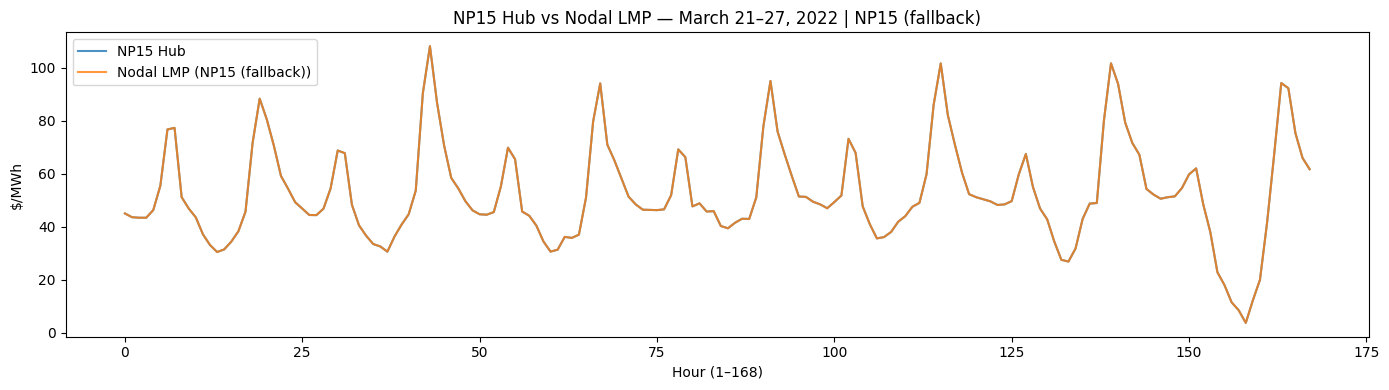


Nodal vs NP15 difference ($/MWh):
count    168.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: lmp_diff, dtype: float64


In [2]:
#PART 1b 
import pandas as pd
import requests
import zipfile
import io
import time
import os
import matplotlib.pyplot as plt


search_names = ["hw_2_Prices.xlsx", "hw 2 Prices.xlsx", "HW2_Prices.xlsx"]
excel_path = None

for name in search_names:
    for folder in [".", os.path.expanduser("~"), os.path.dirname(os.path.abspath("__file__"))]:
        candidate = os.path.join(folder, name)
        if os.path.exists(candidate):
            excel_path = candidate
            break

if excel_path is None:
    
    found = []
    for root, dirs, files in os.walk("."):
        for f in files:
            if f.endswith(".xlsx"):
                found.append(os.path.join(root, f))
    print("Could not find hw_2_Prices.xlsx. xlsx files found:")
    for f in found:
        print(" ", f)
    raise FileNotFoundError("Please set excel_path manually below")
else:
    print(f"Found Excel file: {excel_path}")



# CO2 EMISSION FACTOR
# Source: EPA GHG Emission Factors Hub (2025)
# https://www.epa.gov/system/files/documents/2025-01/ghg-emission-factors-hub-2025.pdf

CO2_PRICE           = 28.30
CO2_EMISSION_FACTOR = 0.05306   
co2_adder           = CO2_PRICE * CO2_EMISSION_FACTOR

print(f"CO2 emission factor : {CO2_EMISSION_FACTOR} tonne CO2/MMBtu")
print(f"CO2 adder           : ${co2_adder:.4f}/MMBtu")

# FIX 2: CAISO OASIS with retry + sleep to avoid 429 (this eventually did not work so i did not end up using it, but here is the code for posterity)
def fetch_caiso_lmp(node, start, end, retries=3, sleep_sec=15):
    url = (
        "http://oasis.caiso.com/oasisapi/SingleZip"
        f"?resultformat=6&queryname=PRC_LMP&version=12"
        f"&market_run_id=DAM&node={node}"
        f"&startdatetime={start}&enddatetime={end}"
    )
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=60)
            if r.status_code == 429:
                wait = sleep_sec * (attempt + 1)
                print(f"  Rate limited. Waiting {wait}s before retry...")
                time.sleep(wait)
                continue
            r.raise_for_status()
        except Exception as e:
            print(f"  Request error for {node}: {e}")
            return None

        if not r.content.startswith(b'PK'):
            print(f"  {node}: not a zip file")
            return None

        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            # Handle both .csv and .xml inside the zip
            csvs = [f for f in z.namelist() if f.endswith('.csv')]
            if not csvs:
                print(f"  {node}: no CSV in zip — files: {z.namelist()}")
                return None
            df = pd.read_csv(z.open(csvs[0]))

        if df.empty:
            print(f"  {node}: empty CSV")
            return None

        # Normalise column names
        col_map = {}
        for c in df.columns:
            cu = c.upper()
            if cu in ('MW', 'LMP_PRC', 'LMP'):   col_map[c] = 'lmp'
            elif cu == 'LOSS_PRC':                col_map[c] = 'mcl'
            elif cu == 'CONGESTION_PRC':          col_map[c] = 'mcc'
            elif 'INTERVALSTART' in cu:           col_map[c] = 'interval_start_utc'
        df = df.rename(columns=col_map)

        if 'lmp' not in df.columns or 'interval_start_utc' not in df.columns:
            print(f"  {node}: unexpected columns: {df.columns.tolist()}")
            return None

        for col in ('mcl', 'mcc'):
            if col not in df.columns:
                df[col] = 0.0

        df['mce'] = df['lmp'] - df['mcl'] - df['mcc']
        df['interval_start_utc'] = pd.to_datetime(df['interval_start_utc'], utc=True)
        df['datetime_pt'] = df['interval_start_utc'].dt.tz_convert('US/Pacific')
        df['date']        = df['datetime_pt'].dt.date
        df['hour_ending'] = df['datetime_pt'].dt.hour + 1

        result = df[['date','hour_ending','lmp','mce','mcc','mcl']]\
                   .sort_values(['date','hour_ending'])\
                   .reset_index(drop=True)
        print(f"  {node}: SUCCESS — {len(result)} rows")
        return result

    print(f"  {node}: all retries exhausted")
    return None

# Try nodes with a pause between each to avoid rate limiting
CANDIDATE_NODES = ["PGSA", "PGSF", "PGF1", "TH_NP15_GEN-APND"]
START = "20220321T07:00-0000"
END   = "20220328T07:00-0000"

lmp_df      = None
active_node = None

for node in CANDIDATE_NODES:
    print(f"\nTrying: {node}")
    time.sleep(10)   # pause between attempts to avoid 429
    lmp_df = fetch_caiso_lmp(node, START, END)
    if lmp_df is not None and len(lmp_df) >= 168:
        active_node = node
        break

# LOAD HW DATASET
elec = pd.read_excel(excel_path, sheet_name="PRICE_ELECTRIC", parse_dates=["OPERATING_DATE"])
elec.columns = ["date", "hour_ending", "np15_price"]
elec["date"] = elec["date"].dt.date

gas = pd.read_excel(excel_path, sheet_name="PRICE_GAS", parse_dates=["OPERATING_DATE"])
gas.columns = ["date", "gas_price"]
gas["date"] = gas["date"].dt.date

prices = elec.merge(gas, on="date", how="left")

# MERGE NODAL LMP OR FALLBACK 
if lmp_df is not None:
    lmp_df.columns = ["date","hour_ending","nodal_lmp","nodal_mce","nodal_mcc","nodal_mcl"]
    prices = prices.merge(lmp_df, on=["date","hour_ending"], how="left")
    print(f"\nUsing nodal LMP from: {active_node}")
else:
    print("\nCAISO API unavailable — using NP15 as fallback for all hours")
    prices["nodal_lmp"] = prices["np15_price"]
    prices["nodal_mce"] = prices["np15_price"]
    prices["nodal_mcc"] = 0.0
    prices["nodal_mcl"] = 0.0
    active_node = "NP15 (fallback)"

prices["co2_adder"]           = co2_adder
prices["effective_fuel_cost"] = prices["gas_price"] + co2_adder
prices["electricity_price"]   = prices["nodal_lmp"]

print(f"\nDataset ready: {prices.shape}")
print(prices[["date","hour_ending","np15_price","nodal_lmp",
              "nodal_mcc","gas_price","effective_fuel_cost"]].head(8).to_string(index=False))

plt.figure(figsize=(14, 4))
plt.plot(prices["np15_price"].values, label="NP15 Hub", alpha=0.8)
plt.plot(prices["nodal_lmp"].values,  label=f"Nodal LMP ({active_node})", alpha=0.8)
plt.xlabel("Hour (1–168)")
plt.ylabel("$/MWh")
plt.title(f"NP15 Hub vs Nodal LMP — March 21–27, 2022 | {active_node}")
plt.legend(); plt.tight_layout(); plt.show()

prices["lmp_diff"] = prices["nodal_lmp"] - prices["np15_price"]
print("\nNodal vs NP15 difference ($/MWh):")
print(prices["lmp_diff"].describe().round(2))

In [ ]:
#TASK 2a: CCGT Bid Table ─



configs = {
    1: {
        'name'    : 'All Off',
        'min_mw'  : 0,   'max_mw': 0,
        'vom'     : 0,
        'avg_hr'  : {'min': 0,      '60': 0,      '80': 0,      '100': 0},
        'incr_hr' : {'minto60': 0,  '60to80': 0,  '80to100': 0},
        'su_fuel' : 0,   'su_cost': 0,
    },
    2: {
        'name'    : '1 CT (Simple Cycle)',
        'min_mw'  : 57,  'max_mw': 190,
        'vom'     : 5.00,
        'avg_hr'  : {'min': 12.591, '60': 10.642, '80': 10.275, '100': 10.133},
        'incr_hr' : {'minto60': 8.692, '60to80': 9.177, '80to100': 9.564},
        'su_fuel' : 220, 'su_cost': 7_250,
    },
    3: {
    
        
        'name'    : '2 CTs Simple Cycle (No Steam)',
        'min_mw'  : 114, 'max_mw': 380,
        'vom'     : 5.00,
        'avg_hr'  : {'min': 12.591, '60': 10.642, '80': 10.275, '100': 10.133},
        'incr_hr' : {'minto60': 8.692, '60to80': 9.177, '80to100': 9.564},
        'su_fuel' : 220, 'su_cost': 7_250,   # incremental: 2nd CT only
    },
    4: {
        'name'    : '1x1 CCGT',
        'min_mw'  : 150, 'max_mw': 340,
        'vom'     : 2.50,
        'avg_hr'  : {'min': 7.695, '60': 7.358, '80': 7.149, '100': 7.048},
        'incr_hr' : {'minto60': 6.421, '60to80': 6.525, '80to100': 6.640},
        'su_fuel' : 850, 'su_cost': 16_500,
    },
    5: {
        # Per assignment: Config 5 SU = Config 4 SU + one CT start
        'name'    : '2x1 CCGT',
        'min_mw'  : 312, 'max_mw': 610,
        'vom'     : 2.00,
        'avg_hr'  : {'min': 7.121, '60': 6.999, '80': 6.839, '100': 6.762},
        'incr_hr' : {'minto60': 6.292, '60to80': 6.361, '80to100': 6.452},
        'su_fuel' : 850 + 220,           # 1,070 MMBtu
        'su_cost' : 16_500 + 7_250,      # $23,750
    },
}

#  FUEL COST 
# Use average gas price across the week as the representative daily fuel cost
# (bid curve is the same every hour of a day, so one price per day is correct)
avg_gas  = prices['gas_price'].mean()
eff_fuel = avg_gas + co2_adder   # gas + CO2 adder from Part 1b

print(f"Average gas price   : ${avg_gas:.4f}/MMBtu")
print(f"CO2 adder           : ${co2_adder:.4f}/MMBtu")
print(f"Effective fuel cost : ${eff_fuel:.4f}/MMBtu\n")

# COMPUTE BID TABLE 
results = {}

for c, p in configs.items():

    if c == 1:
        results[c] = {'su_dollar': 0, 'su_fuel': 0,
                      'ml_dollar': 0, 'ml_fuel': 0,
                      'bid_points': []}
        continue

    min_mw = p['min_mw']
    max_mw = p['max_mw']
    mw_60  = 0.60 * max_mw
    mw_80  = 0.80 * max_mw

    # ML calculations 
    # ML fuel = average heat rate at min load × min load (MW)
    # ML dollar = VOM ($/MWh) × min load (MW)
    ml_fuel   = p['avg_hr']['min'] * min_mw     # MMBtu/hour
    ml_dollar = p['vom'] * min_mw               # $/hour

    # Marginal cost per segment 
    # MC = incremental heat rate × effective fuel cost + VOM
    mc_minto60  = p['incr_hr']['minto60']  * eff_fuel + p['vom']
    mc_60to80   = p['incr_hr']['60to80']   * eff_fuel + p['vom']
    mc_80to100  = p['incr_hr']['80to100']  * eff_fuel + p['vom']

    # Energy bid curve 
    # Each point = (MW output, $/MWh marginal cost for that segment)
    # Starts at minimum load, ends at maximum capacity
    bid_points = [
        (min_mw, round(mc_minto60, 2)),   # min load → 60%
        (mw_60,  round(mc_60to80,  2)),   # 60% → 80%
        (mw_80,  round(mc_80to100, 2)),   # 80% → 100%
        (max_mw, round(mc_80to100, 2)),   # at max capacity
    ]

    results[c] = {
        'su_dollar'  : p['su_cost'],
        'su_fuel'    : p['su_fuel'],
        'ml_dollar'  : round(ml_dollar, 2),
        'ml_fuel'    : round(ml_fuel, 3),
        'bid_points' : bid_points,
    }


for c, r in results.items():
    print(f"{'='*52}")
    print(f"  Configuration {c}: {configs[c]['name']}")
    print(f"{'='*52}")
    if c == 1:
        print("  All off — no bids submitted.\n")
        continue
    print(f"  SU dollar ($/start)              : ${r['su_dollar']:>10,.0f}")
    print(f"  SU fuel   (MMBtu/start)          : {r['su_fuel']:>10,.0f}")
    print(f"  ML dollar ($/hr at min load)     : ${r['ml_dollar']:>10,.2f}")
    print(f"  ML fuel   (MMBtu/hr at min load) : {r['ml_fuel']:>10,.3f}")
    print(f"  Energy Bid Curve:")
    print(f"    {'Pt':<4} {'MW':>8}  {'$/MWh':>8}")
    for i, (mw, price) in enumerate(r['bid_points'], 1):
        print(f"    {i:<4} {mw:>8.1f}  {price:>8.2f}")
    print()

Average gas price   : $7.1014/MMBtu
CO2 adder           : $1.5016/MMBtu
Effective fuel cost : $8.6030/MMBtu

  Configuration 1: All Off
  All off — no bids submitted.

  Configuration 2: 1 CT (Simple Cycle)
  SU dollar ($/start)              : $     7,250
  SU fuel   (MMBtu/start)          :        220
  ML dollar ($/hr at min load)     : $    285.00
  ML fuel   (MMBtu/hr at min load) :    717.687
  Energy Bid Curve:
    Pt         MW     $/MWh
    1        57.0     79.78
    2       114.0     83.95
    3       152.0     87.28
    4       190.0     87.28

  Configuration 3: 2 CTs Simple Cycle (No Steam)
  SU dollar ($/start)              : $     7,250
  SU fuel   (MMBtu/start)          :        220
  ML dollar ($/hr at min load)     : $    570.00
  ML fuel   (MMBtu/hr at min load) :  1,435.374
  Energy Bid Curve:
    Pt         MW     $/MWh
    1       114.0     79.78
    2       228.0     83.95
    3       304.0     87.28
    4       380.0     87.28

  Configuration 4: 1x1 CCGT
  SU d

In [5]:
import subprocess
subprocess.run(["pip", "install", "pulp"], check=True)

CompletedProcess(args=['pip', 'install', 'pulp'], returncode=0)

ERROR: Invalid requirement: '←'

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Rimsha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



Solver  : Optimal
Obj ($) : 166,548.49

  OPERATING SUMMARY — March 21–27, 2022
  Gross Margin      : $     166,548  ($0.2730/kW)
  Capacity Factor   :       20.2%
  Total Revenue     : $   1,647,024
  Total Costs       : $   1,480,476
  Fuel Costs        : $   1,208,309
  VOM Costs         : $      41,480
  Startup (non-fuel): $     166,250
  Startup (fuel)    : $      64,437
  Number of Starts  : 7

First 12 hours of CCGT_CAISO.csv:
OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC  PRICE_GAS  CONFIGURATION_ACTIVE  MW_GENERATION
    2022-03-21            1           45.04       7.05                     1            0.0
    2022-03-21            2           43.63       7.05                     1            0.0
    2022-03-21            3           43.43       7.05                     1            0.0
    2022-03-21            4           43.42       7.05                     1            0.0
    2022-03-21            5           46.30       7.05                     1            0.0
    2022

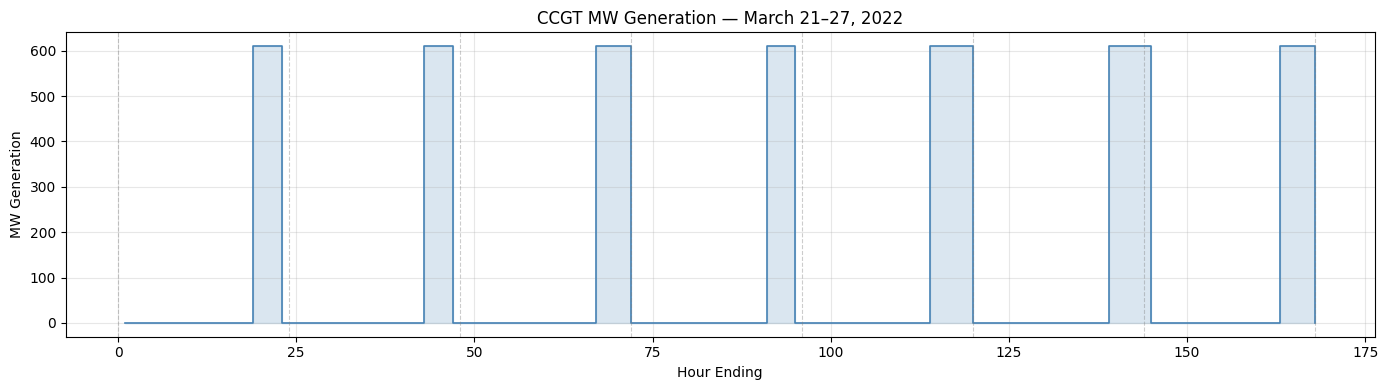

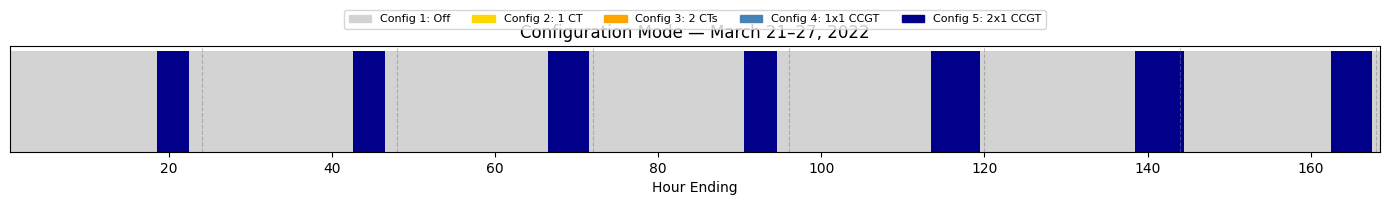

In [ ]:
!pip install pulp -q   ← uncomment if pulp not installed

import pulp
import matplotlib.patches as mpatches

# TASK 2c: CCGT UNIT COMMITMENT & DISPATCH 
T        = 168
CONFIGS  = [1, 2, 3, 4, 5]
MAX_CAP  = 610   # MW, installed capacity of 2x1

cfg = {
    1: dict(name='Off',       min_mw=0,   max_mw=0,   vom=0.00,
            hr_min=0,         incr=[0,      0,      0     ],
            su_fuel=0,        su_cost=0,      mut=0, mdt=0),
    2: dict(name='1 CT',      min_mw=57,  max_mw=190,  vom=5.00,
            hr_min=12.591,    incr=[8.692, 9.177, 9.564],
            su_fuel=220,      su_cost=7_250,  mut=1, mdt=1),
    3: dict(name='2 CTs',     min_mw=114, max_mw=380,  vom=5.00,
            hr_min=12.591,    incr=[8.692, 9.177, 9.564],
            su_fuel=220,      su_cost=7_250,  mut=1, mdt=1),
    4: dict(name='1x1 CCGT',  min_mw=150, max_mw=340,  vom=2.50,
            hr_min=7.695,     incr=[6.421, 6.525, 6.640],
            su_fuel=850,      su_cost=16_500, mut=2, mdt=2),
    5: dict(name='2x1 CCGT',  min_mw=312, max_mw=610,  vom=2.00,
            hr_min=7.121,     incr=[6.292, 6.361, 6.452],
            su_fuel=1_070,    su_cost=23_750, mut=3, mdt=3),
}

# Piecewise segment widths (MW above min load) for each config
for c in CONFIGS:
    mx, mn = cfg[c]['max_mw'], cfg[c]['min_mw']
    cfg[c]['seg'] = [max(0, 0.6*mx - mn), 0.2*mx, 0.2*mx]

elec = prices['electricity_price'].values    # $/MWh
fuel = prices['effective_fuel_cost'].values  # $/MMBtu (gas + CO2)

prob = pulp.LpProblem("CCGT_UC", pulp.LpMaximize)

# u[c,t] = 1 if config c is active at hour t
u = {(c,t): pulp.LpVariable(f"u{c}_{t}", cat='Binary')
     for c in CONFIGS for t in range(T)}

# y[c,t] = 1 if config c starts up at hour t
y = {(c,t): pulp.LpVariable(f"y{c}_{t}", cat='Binary')
     for c in CONFIGS for t in range(T)}

# z[c,t] = 1 if config c shuts down at hour t
z = {(c,t): pulp.LpVariable(f"z{c}_{t}", cat='Binary')
     for c in CONFIGS for t in range(T)}

# s[c,k,t] = MW dispatched in segment k of config c at hour t (above min load)
s = {(c,k,t): pulp.LpVariable(f"s{c}_{k}_{t}", lowBound=0)
     for c in CONFIGS for k in range(3) for t in range(T)}

#OBJECTIVE: Maximize Revenue - Fuel - VOM - Startup Costs 
terms = []
for t in range(T):
    for c in CONFIGS:
        gen = cfg[c]['min_mw'] * u[c,t] + pulp.lpSum(s[c,k,t] for k in range(3))
        terms += [
            +elec[t] * gen,
            -fuel[t] * cfg[c]['hr_min'] * cfg[c]['min_mw'] * u[c,t],
            -pulp.lpSum(fuel[t] * cfg[c]['incr'][k] * s[c,k,t] for k in range(3)),
            -cfg[c]['vom'] * gen,
            -(cfg[c]['su_cost'] + fuel[t] * cfg[c]['su_fuel']) * y[c,t],
        ]
prob += pulp.lpSum(terms)

# CONSTRAINTS 
for t in range(T):

    # 1. Exactly one config active per hour
    prob += pulp.lpSum(u[c,t] for c in CONFIGS) == 1

    for c in CONFIGS:
        # 2. Segment dispatch bounded by active config
        for k in range(3):
            prob += s[c,k,t] <= cfg[c]['seg'][k] * u[c,t]

        # 3. Startup / shutdown indicators
        u_prev = (1 if c == 1 else 0) if t == 0 else u[c, t-1]
        prob += y[c,t] >= u[c,t] - u_prev
        prob += z[c,t] >= u_prev  - u[c,t]
        prob += y[c,t] + z[c,t] <= 1
        prob += y[c,t] <= u[c,t]
        prob += z[c,t] <= 1 - u[c,t]

        # 4. Minimum Up Time
        mut = cfg[c]['mut']
        if mut >= 2 and t + mut <= T:
            prob += (pulp.lpSum(u[c,tau] for tau in range(t, t+mut))
                     >= mut * y[c,t])

        # 5. Minimum Down Time
        mdt = cfg[c]['mdt']
        if mdt >= 2 and t + mdt <= T:
            prob += (pulp.lpSum(1 - u[c,tau] for tau in range(t, t+mdt))
                     >= mdt * z[c,t])

# 6. Initial condition: plant starts fully off
prob += u[1, 0] == 1

# SOLVE
solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=300, gapRel=0.005)
status = prob.solve(solver)
print(f"\nSolver  : {pulp.LpStatus[status]}")
print(f"Obj ($) : {pulp.value(prob.objective):,.2f}")

# EXTRACT RESULTS 
rows = []
total_rev = total_fuel = total_vom = total_su_nf = total_su_f = 0
n_starts  = {c: 0 for c in CONFIGS}

for t in range(T):
    ac      = next(c for c in CONFIGS if pulp.value(u[c,t]) > 0.5)
    segs    = [max(0.0, pulp.value(s[ac,k,t])) for k in range(3)]
    mw      = (cfg[ac]['min_mw'] + sum(segs)) if ac != 1 else 0.0

    rev     = elec[t] * mw
    fc      = fuel[t] * (cfg[ac]['hr_min'] * cfg[ac]['min_mw']
                         + sum(cfg[ac]['incr'][k]*segs[k] for k in range(3)))
    vom_t   = cfg[ac]['vom'] * mw
    started = pulp.value(y[ac,t]) > 0.5

    su_nf = cfg[ac]['su_cost']           * started
    su_f  = fuel[t] * cfg[ac]['su_fuel'] * started
    if started:
        n_starts[ac] += 1

    total_rev    += rev
    total_fuel   += fc
    total_vom    += vom_t
    total_su_nf  += su_nf
    total_su_f   += su_f

    rows.append({
        'OPERATING_DATE'      : prices['date'].iloc[t],
        'HOUR_ENDING'         : int(prices['hour_ending'].iloc[t]),
        'PRICE_ELECTRIC'      : round(elec[t], 2),
        'PRICE_GAS'           : round(prices['gas_price'].iloc[t], 4),
        'CONFIGURATION_ACTIVE': ac,
        'MW_GENERATION'       : round(mw, 2),
    })

results_df  = pd.DataFrame(rows)
results_df.to_csv('CCGT_CAISO.csv', index=False)

total_cost   = total_fuel + total_vom + total_su_nf + total_su_f
gross_margin = total_rev - total_cost
cap_factor   = results_df['MW_GENERATION'].mean() / MAX_CAP * 100
gm_kw        = gross_margin / (MAX_CAP * 1000)
total_starts = sum(v for c,v in n_starts.items() if c != 1)

# SUMMARY 
print(f"\n{'='*48}")
print(f"  OPERATING SUMMARY — March 21–27, 2022")
print(f"{'='*48}")
print(f"  Gross Margin      : ${gross_margin:>12,.0f}  (${gm_kw:.4f}/kW)")
print(f"  Capacity Factor   : {cap_factor:>10.1f}%")
print(f"  Total Revenue     : ${total_rev:>12,.0f}")
print(f"  Total Costs       : ${total_cost:>12,.0f}")
print(f"  Fuel Costs        : ${total_fuel:>12,.0f}")
print(f"  VOM Costs         : ${total_vom:>12,.0f}")
print(f"  Startup (non-fuel): ${total_su_nf:>12,.0f}")
print(f"  Startup (fuel)    : ${total_su_f:>12,.0f}")
print(f"  Number of Starts  : {total_starts}")
print(f"{'='*48}")

print("\nFirst 12 hours of CCGT_CAISO.csv:")
print(results_df.head(12).to_string(index=False))

# ─── PLOT 1: MW vs Hour
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(range(1, T+1), results_df['MW_GENERATION'], where='post',
        color='steelblue', linewidth=1.2)
ax.fill_between(range(1, T+1), results_df['MW_GENERATION'],
                step='post', alpha=0.2, color='steelblue')
for d in range(8):
    ax.axvline(d*24, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax.set_xlabel('Hour Ending'); ax.set_ylabel('MW Generation')
ax.set_title('CCGT MW Generation — March 21–27, 2022')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('mw_vs_hour.png', dpi=150); plt.show()

# ─── PLOT 2: Configuration Mode vs Hour
cmap   = {1:'lightgrey', 2:'gold', 3:'orange', 4:'steelblue', 5:'darkblue'}
clabel = {c: f"Config {c}: {cfg[c]['name']}" for c in CONFIGS}

fig, ax = plt.subplots(figsize=(14, 2.5))
for t in range(T):
    ax.bar(t+1, 1, color=cmap[results_df.loc[t,'CONFIGURATION_ACTIVE']],
           width=1, align='center', edgecolor='none')
for d in range(8):
    ax.axvline(d*24, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_xlabel('Hour Ending'); ax.set_yticks([]); ax.set_xlim(0.5, 168.5)
ax.set_title('Configuration Mode — March 21–27, 2022')
patches = [mpatches.Patch(color=cmap[c], label=clabel[c]) for c in CONFIGS]
ax.legend(handles=patches, ncol=5, fontsize=8,
          bbox_to_anchor=(0.5, 1.4), loc='upper center')
plt.tight_layout(); plt.savefig('config_vs_hour.png', dpi=150); plt.show()

Unit 1 — Optimal  Obj: $30,038.48
  Gross Margin   : $      30,038  ($0.0883/kW)
  Capacity Factor:      8.3%
  Total Revenue  : $     404,563
  Total Costs    : $     374,524
  Fuel Costs     : $     291,097
  Number of Starts: 3

Unit 2 — Optimal  Obj: $239,727.13
  Gross Margin   : $     239,727  ($0.8879/kW)
  Capacity Factor:     31.3%
  Total Revenue  : $   1,058,430
  Total Costs    : $     818,702
  Fuel Costs     : $     781,195
  Number of Starts: 1

First 12 hours of CCGT_PSEUDO.csv:
OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC  PRICE_GAS  MW_GENERATION_Unit1  MW_GENERATION_Unit2
    2022-03-21            1           45.04       7.05                  0.0                  0.0
    2022-03-21            2           43.63       7.05                  0.0                  0.0
    2022-03-21            3           43.43       7.05                  0.0                  0.0
    2022-03-21            4           43.42       7.05                  0.0                  0.0
    2022-03-21 

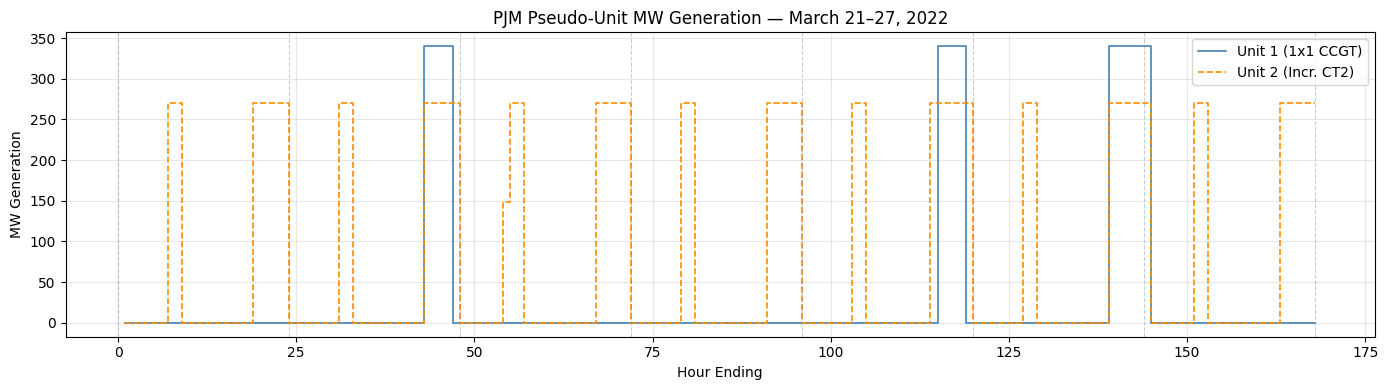

In [ ]:
#qUESTION3 PART B
────

# Pseudo-unit parameters from Task 3a
pseudo = {
    1: dict(
        name     = '1x1 CCGT (Unit 1)',
        min_mw   = 150, max_mw = 340,
        vom      = 2.50,
        hr_min   = 7.695,
        incr     = [6.421, 6.525, 6.640],
        seg      = [54.0, 68.0, 68.0],   # MW widths: 204-150, 272-204, 340-272
        su_fuel  = 850,   su_cost = 16_500,
        mut = 2, mdt = 2,
    ),
    2: dict(
        name     = 'Incremental CT2 (Unit 2)',
        min_mw   = 0,   max_mw = 270,
        vom      = 2.00,
        hr_min   = 0,
        incr     = [6.292, 6.361, 6.452],
        seg      = [26.0, 122.0, 122.0],  # MW widths: 26-0, 148-26, 270-148
        su_fuel  = 220,   su_cost = 7_250,
        mut = 1, mdt = 1,
    ),
}

elec = prices['electricity_price'].values
fuel = prices['effective_fuel_cost'].values

def solve_pseudo_unit(uid, p):
    prob = pulp.LpProblem(f"PU{uid}", pulp.LpMaximize)
    T    = 168

    u = [pulp.LpVariable(f"u{uid}_{t}", cat='Binary')      for t in range(T)]
    y = [pulp.LpVariable(f"y{uid}_{t}", cat='Binary')      for t in range(T)]
    z = [pulp.LpVariable(f"z{uid}_{t}", cat='Binary')      for t in range(T)]
    s = [[pulp.LpVariable(f"s{uid}_{k}_{t}", lowBound=0)
          for k in range(3)] for t in range(T)]

    # Objective
    terms = []
    for t in range(T):
        gen = p['min_mw'] * u[t] + pulp.lpSum(s[t])
        terms += [
            +elec[t] * gen,
            -fuel[t] * p['hr_min'] * p['min_mw'] * u[t],
            -pulp.lpSum(fuel[t] * p['incr'][k] * s[t][k] for k in range(3)),
            -p['vom'] * gen,
            -(p['su_cost'] + fuel[t] * p['su_fuel']) * y[t],
        ]
    prob += pulp.lpSum(terms)

    # Constraints
    for t in range(T):
        for k in range(3):
            prob += s[t][k] <= p['seg'][k] * u[t]

        u_prev = 0 if t == 0 else u[t-1]
        prob += y[t] >= u[t] - u_prev
        prob += z[t] >= u_prev - u[t]
        prob += y[t] + z[t] <= 1
        prob += y[t] <= u[t]
        prob += z[t] <= 1 - u[t]

        if p['mut'] >= 2 and t + p['mut'] <= T:
            prob += pulp.lpSum(u[tau] for tau in range(t, t+p['mut'])) >= p['mut'] * y[t]
        if p['mdt'] >= 2 and t + p['mdt'] <= T:
            prob += pulp.lpSum(1 - u[tau] for tau in range(t, t+p['mdt'])) >= p['mdt'] * z[t]

    # Initial condition: both units start off
    prob += u[0] == 0

    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=120, gapRel=0.005))
    print(f"Unit {uid} — {pulp.LpStatus[prob.status]}  "
          f"Obj: ${pulp.value(prob.objective):,.2f}")

    # Extract results
    rows, n_starts = [], 0
    rev = fuel_c = vom_c = su_nf = su_f = 0

    for t in range(T):
        on      = pulp.value(u[t]) > 0.5
        segs    = [max(0.0, pulp.value(s[t][k])) for k in range(3)]
        mw      = (p['min_mw'] + sum(segs)) if on else 0.0
        started = pulp.value(y[t]) > 0.5

        rev   += elec[t] * mw
        fuel_c += fuel[t] * (p['hr_min']*p['min_mw']*on
                              + sum(p['incr'][k]*segs[k] for k in range(3)))
        vom_c  += p['vom'] * mw
        su_nf  += p['su_cost']           * started
        su_f   += fuel[t] * p['su_fuel'] * started
        if started: n_starts += 1

        rows.append({'t': t, 'mw': round(mw, 2)})

    total_cost   = fuel_c + vom_c + su_nf + su_f
    gross_margin = rev - total_cost
    cap_factor   = sum(r['mw'] for r in rows) / T / p['max_mw'] * 100
    gm_kw        = gross_margin / (p['max_mw'] * 1000)

    print(f"  Gross Margin   : ${gross_margin:>12,.0f}  (${gm_kw:.4f}/kW)")
    print(f"  Capacity Factor: {cap_factor:>8.1f}%")
    print(f"  Total Revenue  : ${rev:>12,.0f}")
    print(f"  Total Costs    : ${total_cost:>12,.0f}")
    print(f"  Fuel Costs     : ${fuel_c:>12,.0f}")
    print(f"  Number of Starts: {n_starts}\n")

    return rows, dict(rev=rev, fuel=fuel_c, vom=vom_c, su_nf=su_nf,
                      su_f=su_f, gm=gross_margin, cf=cap_factor,
                      gm_kw=gm_kw, cost=total_cost, starts=n_starts)

rows1, stats1 = solve_pseudo_unit(1, pseudo[1])
rows2, stats2 = solve_pseudo_unit(2, pseudo[2])

# ── CSV 
pseudo_df = pd.DataFrame({
    'OPERATING_DATE'    : prices['date'].values,
    'HOUR_ENDING'       : prices['hour_ending'].values.astype(int),
    'PRICE_ELECTRIC'    : elec.round(2),
    'PRICE_GAS'         : prices['gas_price'].values.round(4),
    'MW_GENERATION_Unit1': [r['mw'] for r in rows1],
    'MW_GENERATION_Unit2': [r['mw'] for r in rows2],
})
pseudo_df.to_csv('CCGT_PSEUDO.csv', index=False)

print("First 12 hours of CCGT_PSEUDO.csv:")
print(pseudo_df.head(12).to_string(index=False))

# ── PLOT: MW vs Hour 
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(range(1, T+1), pseudo_df['MW_GENERATION_Unit1'],
        where='post', label='Unit 1 (1x1 CCGT)', color='steelblue', lw=1.2)
ax.step(range(1, T+1), pseudo_df['MW_GENERATION_Unit2'],
        where='post', label='Unit 2 (Incr. CT2)', color='darkorange',
        lw=1.2, linestyle='--')
for d in range(8):
    ax.axvline(d*24, color='gray', linestyle='--', alpha=0.4, lw=0.8)
ax.set_xlabel('Hour Ending'); ax.set_ylabel('MW Generation')
ax.set_title('PJM Pseudo-Unit MW Generation — March 21–27, 2022')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('pseudo_mw_vs_hour.png', dpi=150); plt.show()

TASK 4a — Spark Spread Option, k = 7
  Strike (CO2 cost at k=7) : $10.5112/MWh
  Gross Margin             : $763.19/MW
  Capacity Factor          : 26.8%  (45 of 168 hours)

TASK 4b — Best-Match Heat Rate
  Task 2c target GM : $166,548
  Best k for Task 2c: k = 8.67  → GM = $166,353

  Task 3b target GM : $269,765
  Best k for Task 3b: k = 7.94  → GM = $268,967


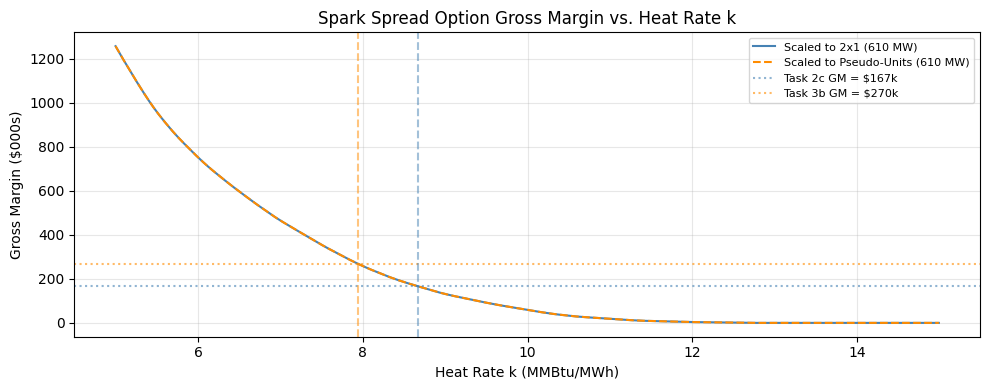

In [ ]:
# ── TASK 4: SPARK SPREAD OPTION 
import numpy as np

elec_p = prices['electricity_price'].values   # $/MWh
gas_p  = prices['gas_price'].values           # $/MMBtu
eff_f  = prices['effective_fuel_cost'].values # gas + CO2 adder

CO2_EF    = 0.05306   # tonne CO2/MMBtu
CO2_PRICE = 28.30     # $/tonne

def spark_spread_option(k):
    """
    For heat rate k (MMBtu/MWh):
      Strike    = k × CO2_EF × CO2_price  ($/MWh)
      Payoff_t  = max(0, λ_t - k × gas_t - Strike)
               = max(0, λ_t - k × effective_fuel_t)
      Gross margin = sum of hourly payoffs ($/MW over 168 hours)
      Capacity factor = fraction of hours in-the-money
    """
    strike   = k * CO2_EF * CO2_PRICE         # $/MWh CO2 component
    payoff   = np.maximum(0, elec_p - k * gas_p - strike)
    # equivalently: np.maximum(0, elec_p - k * eff_f)

    gm       = payoff.sum()                    # $/MW
    cf       = (payoff > 0).sum() / 168 * 100  # %
    hrs      = int((payoff > 0).sum())
    return dict(k=k, strike=round(strike,4), gm=round(gm,2),
                cf=round(cf,1), hrs=hrs, payoff=payoff)

# ── PART a: k = 7 
r7 = spark_spread_option(7)
print("=" * 50)
print(f"TASK 4a — Spark Spread Option, k = {r7['k']}")
print("=" * 50)
print(f"  Strike (CO2 cost at k=7) : ${r7['strike']:.4f}/MWh")
print(f"  Gross Margin             : ${r7['gm']:,.2f}/MW")
print(f"  Capacity Factor          : {r7['cf']}%  ({r7['hrs']} of 168 hours)")

# ── PART b 
TARGET_2C  = 166_548   # Task 2c gross margin ($)
TARGET_3B  = 269_765   # Task 3b combined gross margin ($)
# Task 3b Unit 1 and Unit 2 are each optimized at 1 MW
# For a fair comparison, scale spark spread to MW capacity
CAP_2C  = 610   # MW, 2x1 full capacity
CAP_3B_U1 = 340
CAP_3B_U2 = 270

k_values = np.arange(5.0, 15.0, 0.01)
results  = [spark_spread_option(k) for k in k_values]

# Scale: gross margin per MW × capacity = total $
gm_2c  = np.array([r['gm'] * CAP_2C       for r in results])
gm_3b  = np.array([r['gm'] * (CAP_3B_U1 + CAP_3B_U2) for r in results])

best_2c = results[np.argmin(np.abs(gm_2c - TARGET_2C))]
best_3b = results[np.argmin(np.abs(gm_3b - TARGET_3B))]

print(f"\n{'='*50}")
print(f"TASK 4b — Best-Match Heat Rate")
print(f"{'='*50}")
print(f"  Task 2c target GM : ${TARGET_2C:,.0f}")
print(f"  Best k for Task 2c: k = {best_2c['k']:.2f}  "
      f"→ GM = ${best_2c['gm']*CAP_2C:,.0f}")
print(f"\n  Task 3b target GM : ${TARGET_3B:,.0f}")
print(f"  Best k for Task 3b: k = {best_3b['k']:.2f}  "
      f"→ GM = ${best_3b['gm']*(CAP_3B_U1+CAP_3B_U2):,.0f}")

# ── PLOT: Gross Margin vs k ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_values, gm_2c/1000,  label='Scaled to 2x1 (610 MW)', color='steelblue')
ax.plot(k_values, gm_3b/1000,  label='Scaled to Pseudo-Units (610 MW)', 
        color='darkorange', linestyle='--')
ax.axhline(TARGET_2C/1000,  color='steelblue', linestyle=':', alpha=0.6,
           label=f'Task 2c GM = ${TARGET_2C/1000:.0f}k')
ax.axhline(TARGET_3B/1000,  color='darkorange', linestyle=':', alpha=0.6,
           label=f'Task 3b GM = ${TARGET_3B/1000:.0f}k')
ax.axvline(best_2c['k'], color='steelblue',  linestyle='--', alpha=0.5)
ax.axvline(best_3b['k'], color='darkorange', linestyle='--', alpha=0.5)
ax.set_xlabel('Heat Rate k (MMBtu/MWh)')
ax.set_ylabel('Gross Margin ($000s)')
ax.set_title('Spark Spread Option Gross Margin vs. Heat Rate k')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('spark_spread_k.png', dpi=150); plt.show()